In [1]:
import tensorflow as tf

import matplotlib.pyplot as plt

from tensorflow import keras

import numpy as np

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


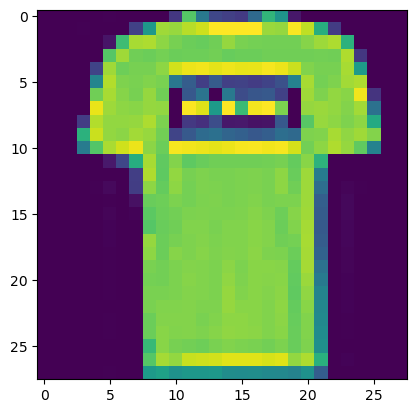

In [3]:
plt.imshow(x_train[1])

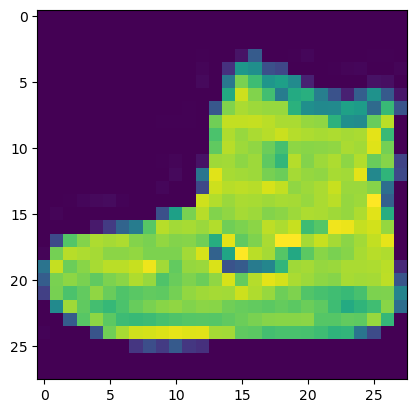

In [4]:
plt.imshow(x_train[0])

In [5]:
x_train = x_train.astype('float32') / 255.0

x_test = x_test.astype('float32') / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)

x_test = x_test.reshape(-1, 28, 28, 1)

In [6]:
print(x_train.shape)

print(x_test.shape)

print(y_train.shape)

print(y_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)
(60000,)
(10000,)


In [7]:
model = keras.Sequential([
    
    keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation='relu'),

    keras.layers.Dropout(0.25),

    keras.layers.Dense(10, activation='softmax')
])

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 3, 3, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 31ms/step - accuracy: 0.7945 - loss: 0.5507 - val_accuracy: 0.8654 - val_loss: 0.3713
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 100s 41ms/step - accuracy: 0.8641 - loss: 0.3693 - val_accuracy: 0.8733 - val_loss: 0.3423
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 35ms/step - accuracy: 0.8806 - loss: 0.3235 - val_accuracy: 0.8924 - val_loss: 0.2958
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.8903 - loss: 0.2957 - val_accuracy: 0.8969 - val_loss: 0.2839
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 32ms/step - accuracy: 0.8970 - loss: 0.2781 - val_accuracy: 0.9034 - val_loss: 0.2601
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 29ms/step - accuracy: 0.9019 - loss: 0.2631 - val_accuracy: 0.9010 - val_loss: 0.2705
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9063 - loss: 0.2505 - val_accuracy: 0.9045 - val_loss: 0.2585
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 74s 29ms/step - accuracy: 0.9097 

In [11]:
test_loss, test_acc = model.evaluate(
    x_test,
    y_test
)

print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9051 - loss: 0.2581
Test accuracy: 0.9050999879837036
